In [2]:
"""! @brief Optimization with Gradient Descent, RMSProp and CMA-ES"""
# @file TP1.ipynb
#
# @mainpage Optimization Project
#
# @section description_main Description
# This project evaluates and compares three optimization algorithms:
# Gradient Descent, RMSProp, and CMA-ES. The goal is to optimize three
# different objective functions while using Optuna to tune hyperparameters.
#
# @section libraries_main Libraries
# - torch (https://docs.pytorch.org/docs/stable/index.html)
#   - Access to tensor and all its operations
# - numpy (https://numpy.org/doc/)
#   - Numerical computing library for array operations
# - matplotlib.pyplot (https://matplotlib.org/stable/index.html)
#   - Access to plot, contour and other visual options
# - optuna (https://optuna.readthedocs.io/en/stable/index.html)
#   - Used to optimize hyperparameters automatically
# - pandas (https://pandas.pydata.org/docs/)
#   - Used to generate tables
# - math (https://docs.python.org/3/library/math.html)
#   - Access to inf
#
# @section authors_main Authors
# - Alejandro Cerdas
# - Kener Castillo
# - Pablo Perez

# Install dependencies

import sys, os

os.system(f'{sys.executable} -m pip install pip --upgrade')
os.system(f'{sys.executable} -m pip install torch optuna matplotlib pandas plotly nbformat')

# Clean previous plots
os.system(f'rm *.png')

1

# Imports

In [3]:
# @brief Imports and global constants declarations

# Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import math


# Global Constants
## Number pi of torch
PI = torch.pi
## Lower Bound used in the plots
MIN_PLOT = -1e1
## Upper Bound used in the plots
MAX_PLOT = 1e1
## Number of points equal spaced for the plot
NUMBER_POINTS= 600
## Number of images of the function to show
LEVELS = 20

## The quote of z for better visualization
Z_PERSPECTIVE = 10

## Random points used to initialize the searches
INITIAL_POINTS = [(torch.rand(2) * 20) - 10 for _ in range(10)]

C:\Users\Luco1421\Desktop\U\ia\TPs\TP1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Utils

In [4]:
# @brief Definition of auxiliar classes

class Function:
    """! The Function base class.
    Defines the function to optimize and its gradient.
    """
    def __init__(self, f, gradient, n):
        """! The function base class initializer.

        @param f The function to be optimized.
        @param gradient The gradient of the function.
        @param n ID of the function (0, 1, 2).

        @return an instance of the Function class
        """
        # Stores the objective function
        self.ob_f = f
        # Stores the gradient function
        self.ob_gradient = gradient
        # Stores the function identifier
        self.n = n

    def f(self, x, y, lib):
        """! Evaluation of the function.
        @param x The x coordinate.
        @param y The y coordinate.
        @param lib The library to use (Torch or Numpy).

        @return Value of the function.
        """
        return self.ob_f(x, y, lib)

    def gradient(self, vec: torch.Tensor):
        """! Evaluation of the gradient of the function.
        @param vec Vector to evaluate

        @return The gradient as a vector
        """
        return self.ob_gradient(vec[0], vec[1])

class Plot:
    """! Class responsible for generating different graphical representations of a two-variable function.

    This class builds a grid over the XY plane using global constants and
    provides methods to generate 3D surfaces, contour plots, contour plots
    with points, surfaces with points, and learning curves.
    """

    def __init__(self):
        """! Initializes the grid used for plotting.

        @return An instance of Plot with points defined in a range and a 2D meshgrid.

        @note This method depends on the following global constants:
              - MIN_PLOT
              - MAX_PLOT
              - NUMBER_POINTS
        """
        # Generate NUMBER_POINTS points in the range of MIN_PLOT and MAX_PLOT
        self.x = np.linspace(MIN_PLOT, MAX_PLOT, NUMBER_POINTS)
        # Generate NUMBER_POINTS points in the range of MIN_PLOT and MAX_PLOT
        self.y = np.linspace(MIN_PLOT, MAX_PLOT, NUMBER_POINTS)
        # Creates 2 numpy 2D arrays with all possible pair of the elements in x and y
        self.X, self.Y = np.meshgrid(self.x, self.y)
        # Saves an iterator used to name the plots
        self.n = 0

    def make_surface(self, fun: Function, f_name):
        """! Generates a 3D surface plot of the function.

        @param fun Function object that provides method `f(x, y, np)`.
        @param f_name Name of the function, used in the plot title.

        @note This method depends on the global constants Z_PERSPECTIVE
        """

        # Evaluates the function over the grid with a clipping function to avoid plotting values outside the needed range
        Z = np.clip(fun.f(self.X, self.Y, np), None, Z_PERSPECTIVE)

        # Creates a new figure for the 3D plot
        fig1 = plt.figure()
        # Adds a 3D subplot to the figure
        ax1 = fig1.add_subplot(111, projection='3d')
        # Plots the surface using the computed Z values
        ax1.plot_surface(self.X, self.Y, Z, cmap='viridis')

        # Labels the axes
        ax1.set_xlabel('x')
        ax1.set_ylabel('y')
        ax1.set_zlabel('f(x,y)')

        # Sets the plot title
        plt.title("Surface of function " + f_name)

    def make_contour(self, fun: Function, f_name):
        """! Generates a 2D contour plot of the function.

        @param fun Function object that provides method `f(x, y, np)`.
        @param f_name Name of the function, used in the plot title.

        @note The number of contour levels depends on the global constant `LEVELS`.
        """
        # Evaluates the function over the grid
        Z = fun.f(self.X, self.Y, np)

        # Creates a new figure for the contour plot
        fig2 = plt.figure()

        # Draws contour lines using the specified number of levels
        plt.contour(self.X, self.Y, Z, levels=LEVELS, cmap='plasma')

        # Adds a color scale to interpret function values
        plt.colorbar()

        # Sets plot title and axis labels
        plt.title(f'Contour of function {f_name}')
        plt.xlabel('x')
        plt.ylabel('y')

    def make_contour_p(self, fun: Function, x, y, name, f_name):
        """! Generates a contour plot with points overlaid.

        @param fun Function object that provides method `f(x, y, np)`.
        @param x Array or list of x-coordinates of the points.
        @param y Array or list of y-coordinates of the points.
        @param name Name of the method or algorithm.
        @param f_name Name of the function, used in the plot title.
        """
        # Evaluates the function over the grid
        Z = fun.f(self.X, self.Y, np)

        # Creates a new figure for the contour plot
        fig3 = plt.figure()

        # Draws contour lines of the function
        plt.contour(self.X, self.Y, Z, levels=25, cmap='plasma')

        # Adds a colorbar to represent function values
        plt.colorbar()

        # Plots the optimization path points with color indicating iteration order
        plt.scatter(x, y, c=[i for i in range(len(x))], cmap='inferno', s=50, label='Points')

        # Sets plot title and axis labels
        plt.title(f'Contour with points of {name} on function {f_name}')
        plt.xlabel('x')
        plt.ylabel('y')

        # Displays the legend
        plt.legend()

    def make_surface_p(self, fun: Function, x, y, z, name, f_name):
        """! Generates a 3D surface plot with points overlaid.

        Draws the function surface and overlays 3D points, useful for
        visualizing optimization steps or sampled solutions.

        @param fun Function object that provides method `f(x, y, np)`.
        @param x Array or list of x-coordinates.
        @param y Array or list of y-coordinates.
        @param z Array or list of z-values (f(x, y)).
        @param name Name of the method or algorithm.
        @param f_name Name of the function, used in the plot title.

        @note This method depends on the global constants Z_PERSPECTIVE
        """
        # Evaluates the function over the grid with a clipping function to avoid plotting values outside the needed range
        Z = np.clip(fun.f(self.X, self.Y, np), None, Z_PERSPECTIVE)

        # Creates a new figure for the 3D plot
        fig4 = plt.figure()

        # Adds a 3D subplot to the figure
        ax1 = fig4.add_subplot(111, projection='3d')

        # Plots the function surface with transparency
        ax1.plot_surface(self.X, self.Y, Z, cmap='viridis', alpha=0.5)

        # Plots optimization points colored by their function value
        ax1.scatter(x, y, z, c=z, cmap='coolwarm', s=60)

        # Labels the axes
        ax1.set_xlabel('x')
        ax1.set_ylabel('y')
        ax1.set_zlabel('f(x,y)')

        # Sets the plot title
        plt.title(f'Surface with points of {name} on function {f_name}')

    @staticmethod
    def make_plot(x, y, name, f_name):
        """! Generates a learning curve plot.

        Plots the evolution of the function value across iterations
        of an algorithm.

        @param x Array or list of iteration indices.
        @param y Array or list of function values at each iteration.
        @param name Name of the method or algorithm.
        @param f_name Name of the function, used in the plot title.
        """
        # Creates a new figure for the plot
        fig5 = plt.figure()

        # Plots function values across iterations
        plt.plot(x, y, marker='o')

        # Sets plot title and axis labels
        plt.title(f'Learning curve of {name} on function {f_name}')
        plt.ylabel('f(x,y)')
        plt.xlabel('Iteration')

    def make_contour_iteration(self, fun: Function, x, y, name, f_name):
        """! Generates a contour plot with points overlaid.

        @param fun Function object that provides method `f(x, y, np)`.
        @param x Array or list of x-coordinates of the points.
        @param y Array or list of y-coordinates of the points.
        @param name Name of the method or algorithm.
        @param f_name Name of the function, used in the plot title.
        """
        # Evaluates the function over the grid
        Z = fun.f(self.X, self.Y, np)

        # Creates a new figure for the contour plot
        fig3 = plt.figure()

        # Draws contour lines of the function
        plt.contour(self.X, self.Y, Z, levels=25, cmap='plasma')

        # Adds a colorbar to represent function values
        plt.colorbar()

        # Plots the optimization path points with color indicating iteration order
        plt.scatter(x, y, color='green', s=50, label='Points')

        # Sets plot title and axis labels
        plt.title(f'Contour with points of {name} on function {f_name}')
        plt.xlabel('x')
        plt.ylabel('y')

        # Displays the legend
        plt.legend()

    @staticmethod
    def show():
        """! Displays all generated plots.
        """

        # Display the plot
        plt.show()

    def save(self):
        """! Saves the plot into an image
        """

        # Save the plot
        plt.savefig(f"grafico{self.n}.png")

        # Increment the iterator
        self.n += 1


# Object Plot initialization
plot = Plot()

class Table:
    """! The Table class
    Defines the functions used to generate, update and show a pandas dataframe
    """
    def __init__(self, data: pd.DataFrame, names):
        """! The Table class initializer
        @param data The panda data frame
        @param names The names used to define the columns in the table

        @return An instance of the Table class initialized with a dataframe with the given columns names
        """

        # The dataframe of the table
        self.data = data

        # Initialize all the columns with the given names
        for name in names:
            self.data[name] = []

    def add(self, run, name, value):
        """! Add a value in a specific column of the table
        @param run Row in the table
        @param name Column in the table
        @param value Value to add in the table
        """

        # Rounds float values for consistency
        if isinstance(value, float):
            value = round(value, 6)

        # Inserts or updates the value in the table
        self.data.loc[run, name] = value

    def show(self):
        """! Show the table
        """

        # Show the dataframe
        print(self.data)

# Funcion 0

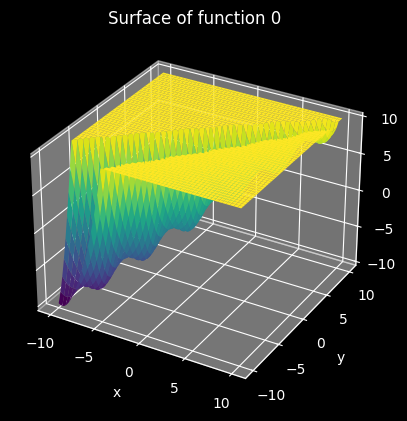

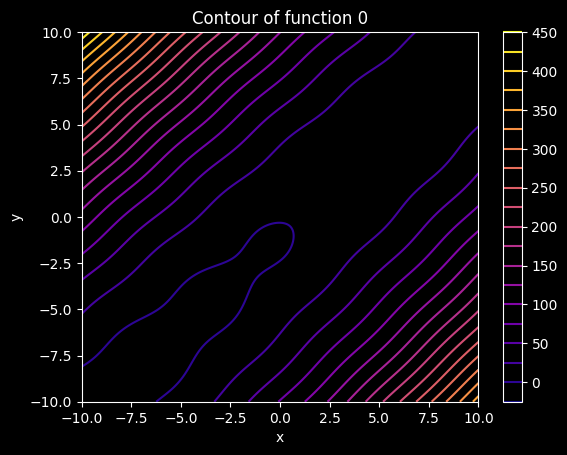

In [5]:
"""! @brief Declaration of the function number 0 and its gradient. """

def f0(x, y, lib):
    """! The function 0.
    @param x A number as the X coordinate.
    @param y A number as the Y coordinate.
    @param lib The library to use sin.

    @return Value of the function in x, y.
    """

    # Evaluate de function in x,y
    return lib.sin(x + y) + (x - y) ** 2 - 1.5 * x + 2.5 * y + 1

def gradient0(x, y):
    """! The gradient of the f0 function.
    @param x A number as the X coordinate.
    @param y A number as the Y coordinate.

    @return A tensor as the gradient in x, y
    """

    # Partial derivative with respect to x
    nx = torch.cos(x + y) + 2*(x - y) - 1.5

    # Partial derivative with respect to y
    ny = torch.cos(x + y) - 2*(x - y) + 2.5

    # Returns gradient vector
    return torch.tensor([nx, ny])


# Initializes function f0 with its gradient
func0 = Function(f0, gradient0, "0")

# Plots the 3D surface of the function
plot.make_surface(func0, func0.n)

# Saves the plot
plot.save()

# Plots the contour of the function
plot.make_contour(func0, func0.n)

# Saves the plot
plot.save()

# Displays all generated plots
plot.show()

# Funcion 1

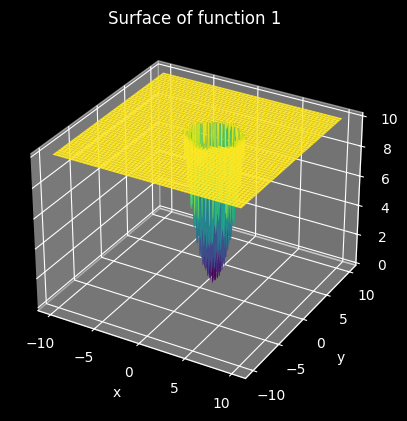

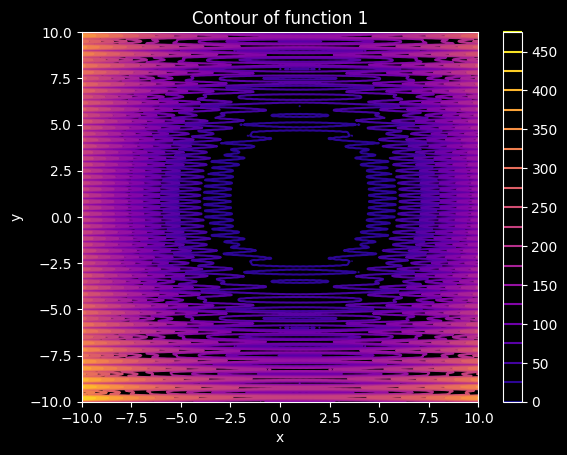

In [6]:
"""! @brief Declaration of the function number 1 and its gradient. """

def gradient1(x,y):
    """! The gradient of the f1 function.
    @param x A number as the X coordinate.
    @param y A number as the Y coordinate.

    @return A tensor as the gradient in x, y
    """

    # Partial derivative with respect to x
    nx = (6*PI*torch.sin(3*PI*x)*torch.cos(3*PI*x))+(2*(x-1)*(1+(torch.sin(3*PI*y)**2)))

    # Partial derivative with respect to y
    ny = (6*PI*(x-1)**2*torch.sin(3*PI*y)*torch.cos(3*PI*y))+(4*PI*(y-1)**2*torch.sin(2*PI*y)*torch.cos(2*PI*y))+2*(y-1)*(1+(torch.sin(2*PI*y)**2))

    # Returns gradient vector
    return torch.tensor([nx, ny])

def f1(x, y, lib):
    """! The function 1.
    @param x A number as the X coordinate.
    @param y A number as the Y coordinate.
    @param lib The library to use sin.

    @return Value of the function in x, y.
    """

    # Evaluate de function in x,y
    return (lib.sin(3 * lib.pi * x) ** 2) + ((x - 1) ** 2) * (1 + (lib.sin(3 * lib.pi * y) ** 2)) + ((y - 1) ** 2) * (1 + lib.sin(2 * lib.pi * y) ** 2)

# Initializes function f1 with its gradient
func1 = Function(f1,gradient1,"1")

# Plots the 3D surface of the function
plot.make_surface(func1, func1.n)

# Saves the plot
plot.save()

# Plots the contour of the function
plot.make_contour(func1, func1.n)

# Saves the plot
plot.save()

# Displays all generated plots
plot.show()

# Funcion 2

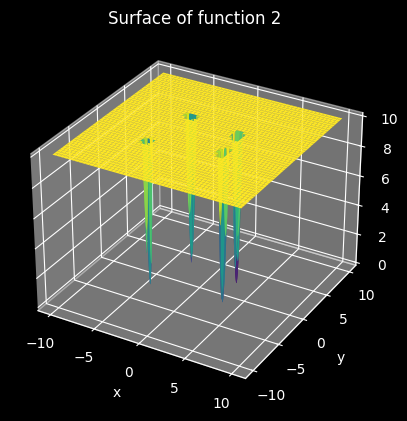

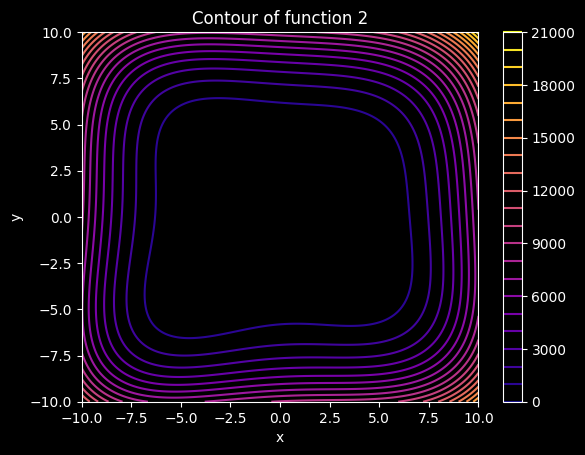

In [7]:
"""! @brief Declaration of the function number 2 and its gradient. """

def gradient2(x,y):
    """! The gradient of the f2 function.
    @param x A number as the X coordinate.
    @param y A number as the Y coordinate.

    @return A tensor as the gradient in x, y
    """

    # Partial derivative with respect to x
    nx = 4*x*(x**2+y-11) + 2*(x+y**2-7)

    # Partial derivative with respect to y
    ny = 2*(x**2+y-11) + 4*y*(x+y**2-7)

    # Returns gradient vector
    return torch.tensor([nx, ny])

def f2(x,y,lib):
    """! The function 2.
    @param x A number as the X coordinate.
    @param y A number as the Y coordinate.
    @param lib The library to use sin.

    @return Value of the function in x, y.
    """
    return (x ** 2 + y - 11) ** 2 + (x + y ** 2 - 7) ** 2

# Initializes function f2 with its gradient
func2 = Function(f2,gradient2,"2")

# Plots the 3D surface of the function
plot.make_surface(func2,func2.n)

# Saves the plot
plot.save()

# Plots the contour of the function
plot.make_contour(func2,func2.n)

# Saves the plot
plot.save()

# Displays all generated plots
plot.show()

# Descenso Gradiente

In [8]:
"""! @brief Declaration of the class GradientDescent"""

class GradientDescent:
    """! The Gradient Descent class.
    The Gradient Descent algorithm, the calibration of its parameters with Optuna and analysis of the best run.
    """
    def __init__(self, fun: Function, table : Table):
        """! Initializes the gradient descent
        @param fun The function to optimize.
        @param table A panda table to show data of the runs of the algorithm.

        @return Initialization of the class.
        """
        # Number of iterations
        self.T = 25

        # Function to be optimized
        self.fun = fun

        # Initial point of the algorithm
        self.x0 = torch.tensor([2, 1])

        # Table to store results
        self.table = table

    def descent(self, alpha: float, x_t):
        """! Executes the algorithm.
        @param alpha Parameter alpha to use.
        @param x_t Tensor as an arbitrary initial point.

        @return An array of the visited points and its function value.
        """
        # List to store visited points
        pts = []

        # List to store function values
        img = []

        # Iterate for a fixed number of steps
        for i in range(self.T):
            # Update the point using gradient descent
            x_t = x_t - alpha * self.fun.gradient(x_t)

            # Clamp values to keep them within [-10, 10]
            x_t = torch.clamp(x_t, -10, 10)

            # Store current point as a Python list
            pts.append(x_t.tolist())

            # Evaluate the function at the current point
            val = self.fun.f(x_t[0], x_t[1], torch)

            # Store the function value
            img.append(val.item())

        # Return visited points and corresponding function values
        return pts, img

    def objetive(self, trial):
        """! Function for Optuna to optimize.
        @param trial An Optuna class.

        @return value of the function in this trial.
        """

        # Alpha suggested by Optuna in the range [1e-5, 1e-1]
        alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)

        # Visited values of the function.
        _, z= self.descent(alpha, self.x0)

        # Return the last value
        return z[-1]

    def study(self):
        """ ! function to calibrate parameters with Optuna.
        @return The best alpha found as a dictionary.
        """

        # Arbitrary initial point for the algorithm.
        self.x0 = torch.tensor([5.0, 5.0])

        # To minimize the function.
        stud = optuna.create_study(direction="minimize")

        # Objective function and number of trials.
        stud.optimize(self.objetive, n_trials=50)

        # Print the best parameters found.
        print(stud.best_params)

        # Visualizations of the process provided by Optuna.
        optuna.visualization.plot_optimization_history(stud).show()
        optuna.visualization.plot_slice(stud, params=["alpha"]).show()

        # Return best parameters found
        return stud.best_params

    def show_plots(self, alpha, init):
        """! Generate plots for the best initial points

        @param alpha The hyperparameter alpha of the algorithm.
        @param init The initial point of the algorithm.
        """
        # Executes the optimization algorithm
        pts, img = self.descent(alpha, init)

        # Plots contour with optimization trajectory
        plot.make_contour_p(
            self.fun,
            [x[0] for x in pts],
            [x[1] for x in pts],
            "Descenso de Gradiente",
            self.fun.n
        )

        # Plots surface with optimization points
        plot.make_surface_p(
            self.fun,
            [x[0] for x in pts],
            [x[1] for x in pts],
            img,
            "Descenso de Gradiente",
            self.fun.n
        )

        # Plots learning curve (function value vs iterations)
        plot.make_plot(
            [i for i in range(len(pts))],
            [i for i in img],
            "Descenso de Gradiente",
            self.fun.n
        )

        # Displays all generated plots
        plot.show()

    def run(self):
        """! Run 10 times the algorithm with the optimized parameters and show the best one with grophs.
        """
        # Retrieve best parameters from optimization study
        best = self.study()
        alpha = best["alpha"]

        # Iteration counter
        it = 0

        # Initialize best distance tracker:
        # [minimum function value, iteration index where it occurred]
        best_dist = [math.inf, math.inf]

        # Store the best initial point found, initialized with infinit
        best_init = torch.tensor([math.inf, math.inf])

        # Iterate over predefined initial points
        for i in INITIAL_POINTS:
            # Run descent algorithm for current initial point
            pts, img = self.descent(alpha, i)

            # Find index of minimum function value
            idx = img.index(min(img))

            # Store results in table
            self.table.add(it, "Iteration", idx)
            self.table.add(it, "X", i[0].item())
            self.table.add(it, "Y", i[1].item())
            self.table.add(it, "Alpha", alpha)
            self.table.add(it, "Z min", min(img))
            self.table.add(it, "Z max", max(img))
            self.table.add(it, "Z end", img[-1])

            # Update best result if current one is better
            if [min(img), idx] < best_dist:
                best_dist = [min(img), idx]
                best_init = i

            # Increment iteration counter
            it += 1

        # Display results table
        self.table.show()

        # Generate plots using the best initial point found
        self.show_plots(alpha, best_init)

# RMS Prop

In [9]:
"""! @brief Declaration of the class RMSProp"""

class RMSProp:
    """! RMS prop algorithm class
    The Gradient Descent algorithm, the calibration of its parameters with Optuna and analysis of the best run.
    """

    def __init__(self, fun: Function, table : Table):
        """! Initialize the RMSProp class

        @param fun The function to be optimized.
        @param table A panda table to show data of the runs of the algorithm.

        @return An instance of the RMS prop class with the function and the table
        """
        #Number of iterations
        self.T = 25

        # Function to be optimized
        self.fun = fun

        # Initial point of the algorithm
        self.x0 = torch.tensor([5.0, 5.0])

        # Table to store results
        self.table = table

    def descent(self, x_t, rho: float, gamma: float):
        """! Executes the algorithm.

        @param gamma Parameter gamma to use.
        @param rho Parameter rho to use.
        @param x_t Tensor as an arbitrary initial point.

        @return An array of the visited points and its function value.
        """

        # List to store visited points
        pts = []

        # List to store the image of the visited points
        img = []

        # Epsilon used to calculate the alpha vector
        eps = 1e-15 # could be smaller

        # Accumulated of the gradients of the previous steps
        s_i = torch.zeros(2, dtype=torch.float32)

        # Execute the algorithm for a fixed number of steps
        for i in range(self.T):

            # Calculate the gradient vector in point x_t
            grad = self.fun.gradient(x_t)

            # Update s_i vector
            s_i = s_i * gamma + grad * grad * (1 - gamma)

            # Update alpha
            alpha = rho / torch.sqrt(s_i + eps)

            # Update the point using gradient descent
            x_t = x_t - alpha * grad

            # Build a domain for a visualization
            pts.append(x_t.tolist())

            # Build a codomain for a visualization
            val=self.fun.f(x_t[0], x_t[1], torch)
            img.append(val.item())

        # Return the visited points and the corresponding function values
        return pts, img

    def objetive(self, trial):
        """! Function for Optuna to optimize.
        @param trial An Optuna class.

        @return value of the function in this trial.
        """

        # Rho suggested by Optuna in the range [1e-11, 1]
        rho = trial.suggest_float("rho", 1e-11, 1, log=True)

        # Gamma suggested by Optuna in the range [1e-11, 1]
        gamma = trial.suggest_float("gamma", 1e-11, 1, log=True)

        # Visited values of the function.
        _, z= self.descent(self.x0, rho, gamma)

        # Return the last value
        return z[-1]

    def study(self):
        """ ! function to calibrate parameters with Optuna.
        @return The best parameters found as a dictionary.
        """

        # Arbitrary initial point for the algorithm.
        self.x0 = torch.tensor([5.0, 5.0])

        # To minimize the function.
        stud = optuna.create_study(direction="minimize")

        # Objective function and number of trials.
        stud.optimize(self.objetive, n_trials=50)

        # Print the best parameters found.
        print(stud.best_params)

        # Visualizations of the process provided by Optuna.
        optuna.visualization.plot_optimization_history(stud).show()
        optuna.visualization.plot_slice(stud, params=["rho", "gamma"]).show()

        # Return the best parameters found
        return stud.best_params

    def show_plots(self, gamma, rho, init):
        """! Show different plots for the best configuration found
        @param alpha The hyperparameter gamma of the algorithm.
        @param rho The hyperparameter rho of the algorithm.
        @param init The initial point of the algorithm.
        """
        # Executes the optimization algorithm
        pts, img = self.descent(init, rho, gamma)

        # Plots contour with optimization trajectory
        plot.make_contour_p(
            self.fun,
            [x[0] for x in pts],
            [x[1] for x in pts],
            "RMSProp",
            self.fun.n
        )

        # Plots surface with optimization points
        plot.make_surface_p(
            self.fun,
            [x[0] for x in pts],
            [x[1] for x in pts],
            img,
            "RMSProp",
            self.fun.n
        )

        # Plots learning curve (function value vs iterations)
        plot.make_plot(
            range(len(pts)),
            img,
            "RMSProp",
            self.fun.n
        )

        # Displays all generated plots
        plot.show()

    def run(self):
        """! Run 10 times the algorithm with the optimized parameters and show the best one with graphs.
        """
        # Select the best values of the study
        best = self.study()

        # Assign the best values to the variables
        rho, gamma = best["rho"], best["gamma"]

        # Initialize the iteration counter
        it = 0

        # Initialize the best distance tracker:
        best_dist = [math.inf, math.inf]
        best_init = torch.tensor([math.inf, math.inf])

        # Iterate over predefined initial points
        for i in INITIAL_POINTS:
            # Run the descent algorithm
            points, images = self.descent(i, rho, gamma)

            # Find the index of the minimum function value
            idx = images.index(min(images))

            # Add results to the table
            self.table.add(it, "X", i[0].item())
            self.table.add(it, "Y", i[1].item())
            self.table.add(it, "Rho", rho)
            self.table.add(it, "Gamma", gamma)
            self.table.add(it, "Z min", min(images))
            self.table.add(it, "Iteration", idx)
            self.table.add(it, "Z max", max(images))
            self.table.add(it, "Z end", images[-1])

            # Update the best result if the current one is better
            if [min(images), idx] < best_dist:
                best_dist = [min(images), idx]
                best_init = i
            it += 1

        # Display the results
        self.table.show()
        self.show_plots(gamma, rho, best_init)


# Análisis con Optuna

[I 2026-05-12 00:55:26,633] A new study created in memory with name: no-name-c84354f7-4906-48a5-97db-d1ca69feb918
[I 2026-05-12 00:55:26,639] Trial 0 finished with value: 5.39311408996582 and parameters: {'alpha': 0.00031486787961857815}. Best is trial 0 with value: 5.39311408996582.
[I 2026-05-12 00:55:26,643] Trial 1 finished with value: 4.538642883300781 and parameters: {'alpha': 0.01011744873664888}. Best is trial 1 with value: 4.538642883300781.
[I 2026-05-12 00:55:26,647] Trial 2 finished with value: 5.352273941040039 and parameters: {'alpha': 0.0005301267755491022}. Best is trial 1 with value: 4.538642883300781.
[I 2026-05-12 00:55:26,651] Trial 3 finished with value: 4.4186248779296875 and parameters: {'alpha': 0.017716738500848823}. Best is trial 3 with value: 4.4186248779296875.
[I 2026-05-12 00:55:26,655] Trial 4 finished with value: 5.40329647064209 and parameters: {'alpha': 0.0002625625512108203}. Best is trial 3 with value: 4.4186248779296875.
[I 2026-05-12 00:55:26,659] 

{'alpha': 0.0990464377667196}


          X         Y     Alpha  Iteration      Z min       Z max      Z end
0 -3.076737 -7.046052  0.099046       24.0  -5.051245   -1.219059  -5.051245
1 -8.789130  8.805107  0.099046       24.0  -1.913112  125.637947  -1.913112
2 -8.915907  7.264505  0.099046       24.0  -1.913218  105.761383  -1.913218
3 -2.639543 -1.743213  0.099046       24.0  -5.028531    0.059143  -5.028531
4 -2.180393 -6.085358  0.099046       22.0  -5.054815   -1.974360  -5.054815
5 -8.630865 -8.735422  0.099046       24.0 -10.122130   -7.469704 -10.122130
6 -7.169003 -1.497990  0.099046       24.0  -5.054812   11.194952  -5.054812
7 -3.004156  0.603686  0.099046       24.0  -1.913219    5.855304  -1.913219
8  0.622189  1.721140  0.099046       24.0   1.236576    3.485748   1.236576
9  5.598886  3.790258  0.099046       24.0   4.370112    4.919187   4.370112


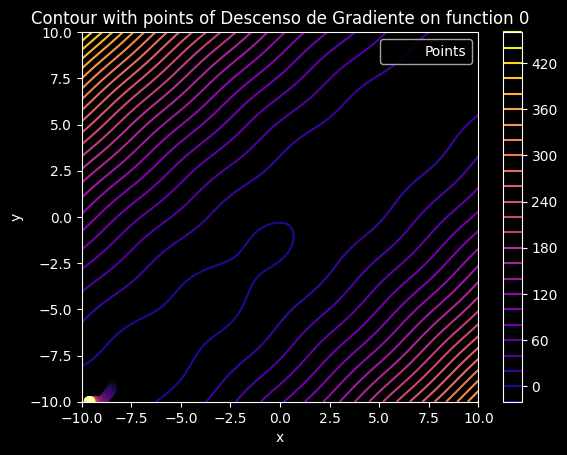

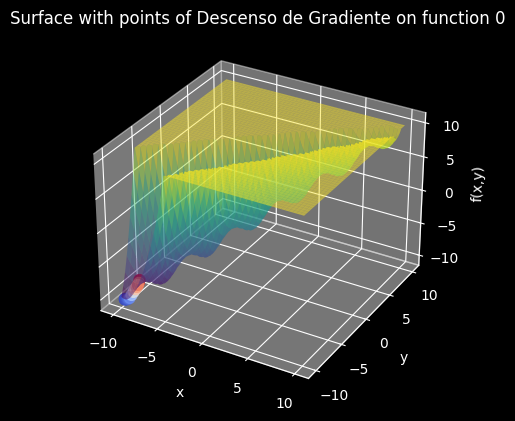

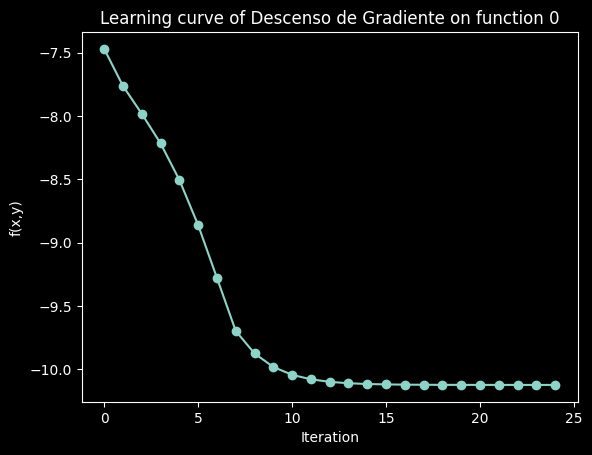

In [10]:
"""! @brief Initializes Gradient Descent for function f0 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
GD0 = GradientDescent(
    func0,
    Table(pd.DataFrame(), ["X", "Y", "Alpha", "Iteration", "Z min", "Z max", "Z end"])
)

# Executes the Gradient Descent algorithm
GD0.run()

[I 2026-05-12 00:55:36,288] A new study created in memory with name: no-name-c78793ff-65e8-439d-9347-c0e6f675d360
[I 2026-05-12 00:55:36,297] Trial 0 finished with value: 31.817291259765625 and parameters: {'alpha': 0.00032226722979116347}. Best is trial 0 with value: 31.817291259765625.
[I 2026-05-12 00:55:36,306] Trial 1 finished with value: 31.900880813598633 and parameters: {'alpha': 7.919144540951451e-05}. Best is trial 0 with value: 31.817291259765625.
[I 2026-05-12 00:55:36,314] Trial 2 finished with value: 31.964019775390625 and parameters: {'alpha': 1.92306054090023e-05}. Best is trial 0 with value: 31.817291259765625.
[I 2026-05-12 00:55:36,322] Trial 3 finished with value: 21.070165634155273 and parameters: {'alpha': 0.006470068882331003}. Best is trial 3 with value: 21.070165634155273.
[I 2026-05-12 00:55:36,330] Trial 4 finished with value: 0.5603549480438232 and parameters: {'alpha': 0.07633926449305403}. Best is trial 4 with value: 0.5603549480438232.
[I 2026-05-12 00:55

{'alpha': 0.04322708509048758}


          X         Y     Alpha  Iteration     Z min       Z max     Z end
0 -3.076737 -7.046052  0.043227       12.0  0.142221  141.831024  1.676244
1 -8.789130  8.805107  0.043227       21.0  0.820469  218.501480  2.497833
2 -8.915907  7.264505  0.043227       24.0  2.076962  253.119247  2.076962
3 -2.639543 -1.743213  0.043227       21.0  1.734580  142.280884  2.496165
4 -2.180393 -6.085358  0.043227       12.0  0.635170  148.377167  1.020411
5 -8.630865 -8.735422  0.043227       23.0  1.275141  234.476212  2.054581
6 -7.169003 -1.497990  0.043227       24.0  3.257978  157.565475  3.257978
7 -3.004156  0.603686  0.043227       23.0  0.299480   69.531624  0.800063
8  0.622189  1.721140  0.043227       23.0  0.106757    3.373527  0.829383
9  5.598886  3.790258  0.043227       22.0  0.755517  145.106995  2.144308


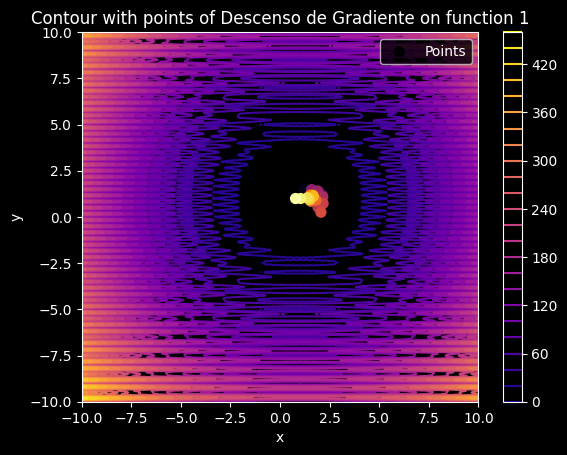

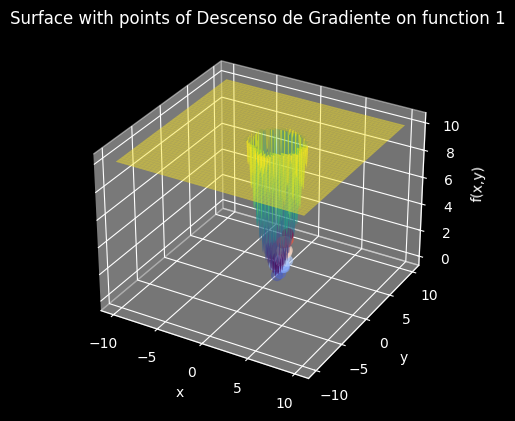

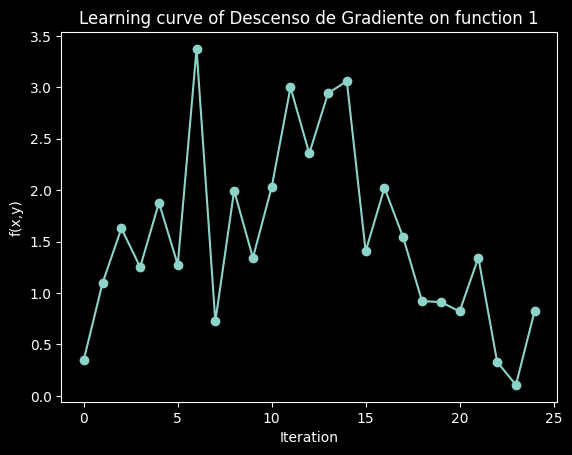

In [11]:
"""! @brief Initializes Gradient Descent for function f1 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
GD1 = GradientDescent(func1, Table(pd.DataFrame(), ["X","Y","Alpha","Iteration","Z min", "Z max", "Z end"]))

# Executes the Gradient Descent algorithm
GD1.run()

[I 2026-05-12 00:55:41,979] A new study created in memory with name: no-name-47ae4f24-6cfa-4268-a356-fd6212bf8f35
[I 2026-05-12 00:55:41,985] Trial 0 finished with value: 0.0003072095278184861 and parameters: {'alpha': 0.012073527092265293}. Best is trial 0 with value: 0.0003072095278184861.
[I 2026-05-12 00:55:41,990] Trial 1 finished with value: 299.9178161621094 and parameters: {'alpha': 0.00010724578775222117}. Best is trial 0 with value: 0.0003072095278184861.
[I 2026-05-12 00:55:41,996] Trial 2 finished with value: 468.2215576171875 and parameters: {'alpha': 5.9055828484758746e-05}. Best is trial 0 with value: 0.0003072095278184861.
[I 2026-05-12 00:55:42,001] Trial 3 finished with value: 462.32147216796875 and parameters: {'alpha': 6.0343403173044674e-05}. Best is trial 0 with value: 0.0003072095278184861.
[I 2026-05-12 00:55:42,006] Trial 4 finished with value: 133.64651489257812 and parameters: {'alpha': 0.00021099656888458817}. Best is trial 0 with value: 0.000307209527818486

{'alpha': 0.00717465641703709}


          X         Y     Alpha  Iteration        Z min        Z max  \
0 -3.076737 -7.046052  0.007175       23.0     0.000000   194.270538   
1 -8.789130  8.805107  0.007175        1.0  7185.917480  8590.490234   
2 -8.915907  7.264505  0.007175        0.0  7473.332520  7729.052246   
3 -2.639543 -1.743213  0.007175       24.0     0.000000    53.018768   
4 -2.180393 -6.085358  0.007175       24.0     0.000000    86.419800   
5 -8.630865 -8.735422  0.007175       24.0     0.020557   991.777100   
6 -7.169003 -1.497990  0.007175       24.0     0.000004   158.100571   
7 -3.004156  0.603686  0.007175       24.0     0.000000    89.300926   
8  0.622189  1.721140  0.007175       24.0     0.002727    73.195641   
9  5.598886  3.790258  0.007175       24.0     0.000539    45.487900   

         Z end  
0     0.000000  
1  7729.897461  
2  7713.315918  
3     0.000000  
4     0.000000  
5     0.020557  
6     0.000004  
7     0.000000  
8     0.002727  
9     0.000539  


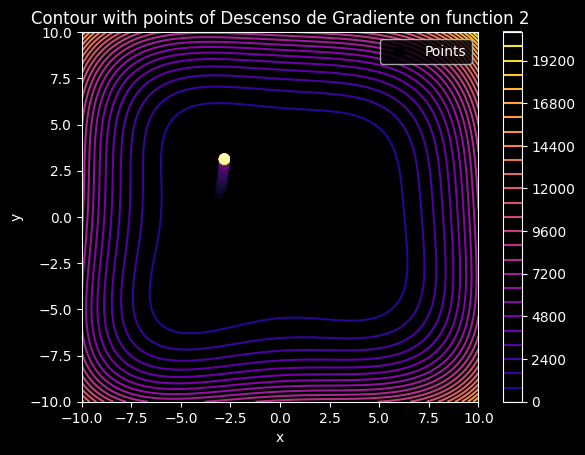

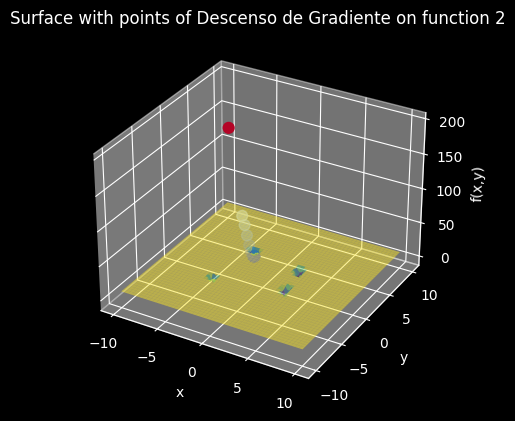

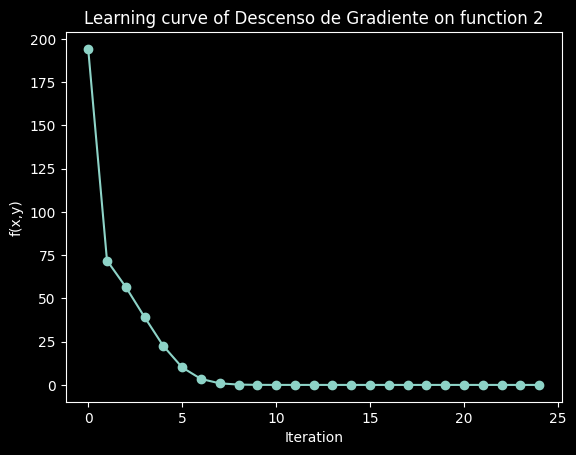

In [12]:
"""! @brief Initializes Gradient Descent for function f2 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
GD2 = GradientDescent(func2, Table(pd.DataFrame(), ["X","Y","Alpha","Iteration","Z min", "Z max","Z end"]))

# Executes the Gradient Descent algorithm
GD2.run()

[I 2026-05-12 00:55:47,817] A new study created in memory with name: no-name-908482ff-5f3b-4008-99db-88c146290829
[I 2026-05-12 00:55:47,823] Trial 0 finished with value: 5.4559783935546875 and parameters: {'rho': 3.9387987852427316e-11, 'gamma': 2.3754548862659573e-06}. Best is trial 0 with value: 5.4559783935546875.
[I 2026-05-12 00:55:47,827] Trial 1 finished with value: 5.4559783935546875 and parameters: {'rho': 1.1837451446138888e-09, 'gamma': 4.815567127513779e-09}. Best is trial 0 with value: 5.4559783935546875.
[I 2026-05-12 00:55:47,832] Trial 2 finished with value: 5.455788612365723 and parameters: {'rho': 1.9298511285569874e-06, 'gamma': 1.340892427294e-11}. Best is trial 2 with value: 5.455788612365723.
[I 2026-05-12 00:55:47,837] Trial 3 finished with value: 4.37286376953125 and parameters: {'rho': 0.04050278211590113, 'gamma': 2.325053867942115e-11}. Best is trial 3 with value: 4.37286376953125.
[I 2026-05-12 00:55:47,842] Trial 4 finished with value: 5.455931663513184 an

{'rho': 0.03859615783239699, 'gamma': 5.181352760641799e-10}


          X         Y       Rho  Gamma  Iteration       Z min       Z max  \
0 -3.076737 -7.046052  0.038596    0.0       24.0   -3.338124    3.945675   
1 -8.789130  8.805107  0.038596    0.0       24.0  277.727173  342.904907   
2 -8.915907  7.264505  0.038596    0.0       24.0  230.758484  290.697693   
3 -2.639543 -1.743213  0.038596    0.0       24.0   -1.259757    2.064045   
4 -2.180393 -6.085358  0.038596    0.0       24.0   -4.098357    2.947008   
5 -8.630865 -8.735422  0.038596    0.0       24.0   -9.091879   -7.017438   
6 -7.169003 -1.497990  0.038596    0.0       24.0   17.458225   38.457672   
7 -3.004156  0.603686  0.038596    0.0       24.0    5.296518   18.651440   
8  0.622189  1.721140  0.038596    0.0       24.0    1.916420    5.975319   
9  5.598886  3.790258  0.038596    0.0       22.0    4.373993    5.265196   

        Z end  
0   -3.338124  
1  277.727173  
2  230.758484  
3   -1.259757  
4   -4.098357  
5   -9.091879  
6   17.458225  
7    5.296518  
8    1.9

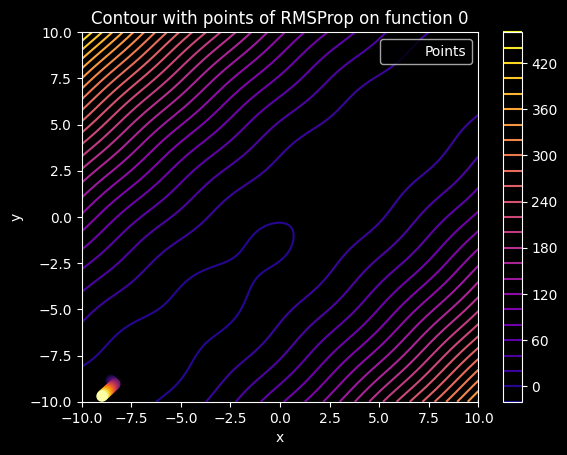

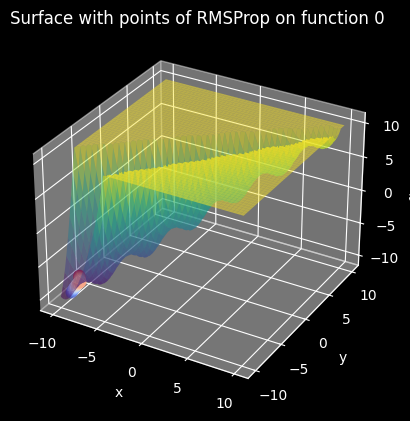

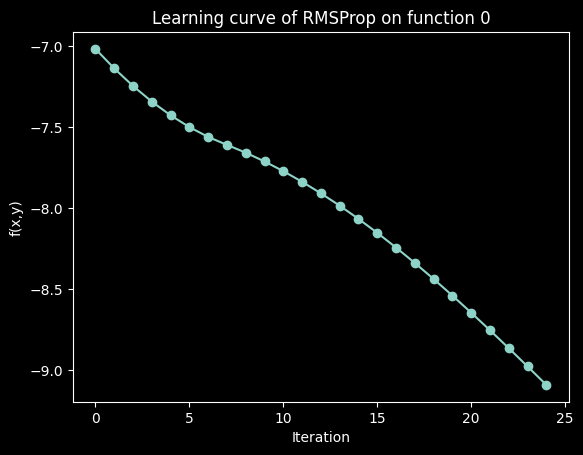

In [13]:
"""! @brief Initializes RMSProp for function f0 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
RMS0 = RMSProp(func0, Table(pd.DataFrame(), ["X","Y","Rho","Gamma","Iteration","Z min", "Z max","Z end"]))

# Executes the RMSProp algorithm
RMS0.run()

[I 2026-05-12 00:55:55,720] A new study created in memory with name: no-name-35d359fc-3cc0-4553-8094-dbe57054cf32
[I 2026-05-12 00:55:55,730] Trial 0 finished with value: 31.827083587646484 and parameters: {'rho': 0.0012738017908200975, 'gamma': 0.22917800142796507}. Best is trial 0 with value: 31.827083587646484.
[I 2026-05-12 00:55:55,739] Trial 1 finished with value: 32.0 and parameters: {'rho': 5.894589067733457e-10, 'gamma': 3.0952668120995816e-07}. Best is trial 0 with value: 31.827083587646484.
[I 2026-05-12 00:55:55,748] Trial 2 finished with value: 31.80843734741211 and parameters: {'rho': 0.003990172122055788, 'gamma': 1.7254844201422184e-09}. Best is trial 2 with value: 31.80843734741211.
[I 2026-05-12 00:55:55,756] Trial 3 finished with value: 167.33985900878906 and parameters: {'rho': 0.9831138393586938, 'gamma': 3.332658563988504e-06}. Best is trial 2 with value: 31.80843734741211.
[I 2026-05-12 00:55:55,765] Trial 4 finished with value: 31.94011688232422 and parameters: 

{'rho': 0.637519128872921, 'gamma': 0.7801638100772295}


          X         Y       Rho     Gamma  Iteration      Z min       Z max  \
0 -3.076737 -7.046052  0.637519  0.780164       21.0  34.407242  123.948792   
1 -8.789130  8.805107  0.637519  0.780164       24.0  30.790577  171.763092   
2 -8.915907  7.264505  0.637519  0.780164        8.0  78.225800  279.126007   
3 -2.639543 -1.743213  0.637519  0.780164       14.0   1.367028   20.581339   
4 -2.180393 -6.085358  0.637519  0.780164       19.0   2.467578   70.029335   
5 -8.630865 -8.735422  0.637519  0.780164       14.0  47.830708  192.822769   
6 -7.169003 -1.497990  0.637519  0.780164       18.0   1.994633   92.495407   
7 -3.004156  0.603686  0.637519  0.780164       16.0   0.179897   10.494085   
8  0.622189  1.721140  0.637519  0.780164       17.0   0.323176   10.746211   
9  5.598886  3.790258  0.637519  0.780164       23.0   0.342888   20.109615   

        Z end  
0   43.105721  
1   30.790577  
2  166.555298  
3    1.430819  
4    4.245893  
5   65.362251  
6    4.358773  
7 

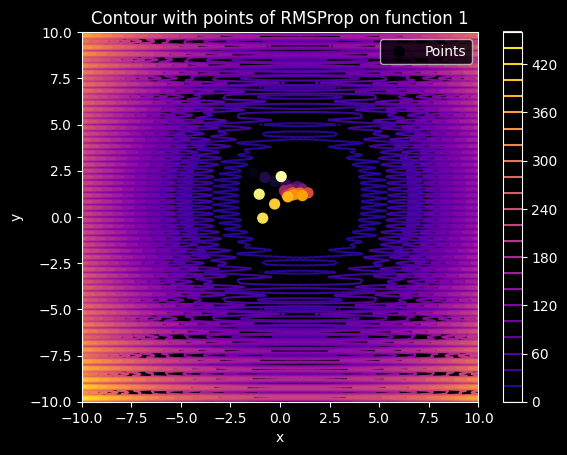

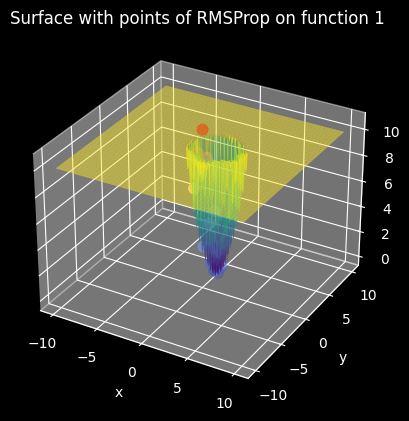

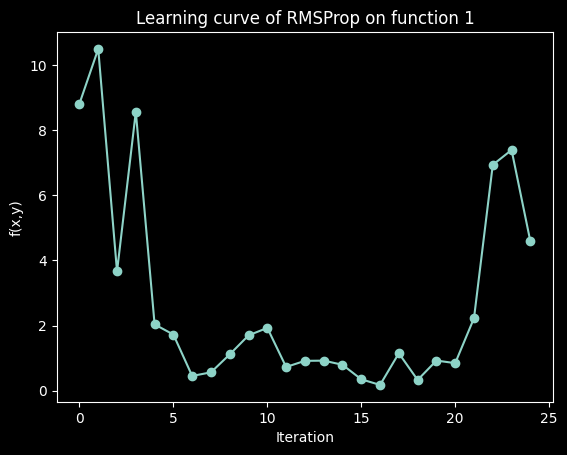

In [14]:
"""! @brief Initializes RMSProp for function f1 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
RMS1 = RMSProp(func1, Table(pd.DataFrame(), ["X","Y","Rho","Gamma","Iteration","Z min", "Z max","Z end"]))

# Executes the RMSProp algorithm
RMS1.run()

[I 2026-05-12 00:56:02,488] A new study created in memory with name: no-name-f465c0ac-93da-40d4-b005-a5a52e5f4293
[I 2026-05-12 00:56:02,495] Trial 0 finished with value: 890.0 and parameters: {'rho': 1.5407958561051873e-10, 'gamma': 1.2617180123803624e-07}. Best is trial 0 with value: 890.0.
[I 2026-05-12 00:56:02,501] Trial 1 finished with value: 890.0 and parameters: {'rho': 2.235892257668319e-10, 'gamma': 1.315765036006037e-10}. Best is trial 0 with value: 890.0.
[I 2026-05-12 00:56:02,507] Trial 2 finished with value: 890.0 and parameters: {'rho': 2.9226551825995364e-11, 'gamma': 3.135151903116156e-09}. Best is trial 0 with value: 890.0.
[I 2026-05-12 00:56:02,513] Trial 3 finished with value: 890.0 and parameters: {'rho': 1.5676455206726649e-09, 'gamma': 8.173540670825611e-09}. Best is trial 0 with value: 890.0.
[I 2026-05-12 00:56:02,518] Trial 4 finished with value: 1.6687849760055542 and parameters: {'rho': 0.16583197477092712, 'gamma': 5.8468396342358526e-08}. Best is trial 4

{'rho': 0.11872033128508704, 'gamma': 5.4731601024566455e-08}


          X         Y      Rho  Gamma  Iteration        Z min        Z max  \
0 -3.076737 -7.046052  0.11872    0.0       24.0    32.784573  1487.812988   
1 -8.789130  8.805107  0.11872    0.0       24.0  1276.571045  8882.925781   
2 -8.915907  7.264505  0.11872    0.0       24.0   852.578308  6651.208008   
3 -2.639543 -1.743213  0.11872    0.0       12.0     0.297257    67.186234   
4 -2.180393 -6.085358  0.11872    0.0       23.0     0.416536   828.215576   
5 -8.630865 -8.735422  0.11872    0.0       24.0   658.473083  6241.903809   
6 -7.169003 -1.497990  0.11872    0.0       24.0    11.162330  1506.446045   
7 -3.004156  0.603686  0.11872    0.0       20.0     0.265644    91.486069   
8  0.622189  1.721140  0.11872    0.0       19.0     0.031835    82.412567   
9  5.598886  3.790258  0.11872    0.0       21.0     0.227002   658.510803   

         Z end  
0    32.784573  
1  1276.571045  
2   852.578308  
3     0.297257  
4     0.520347  
5   658.473083  
6    11.162330  
7    

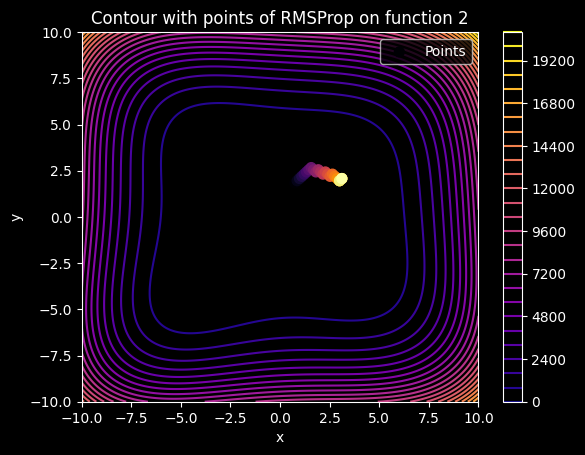

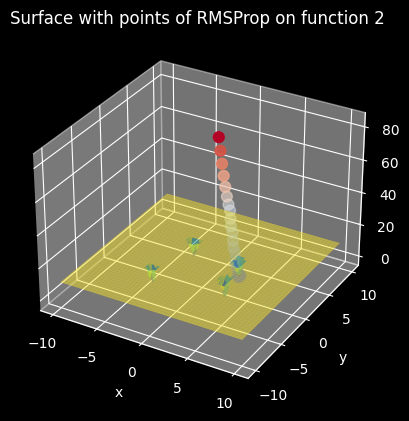

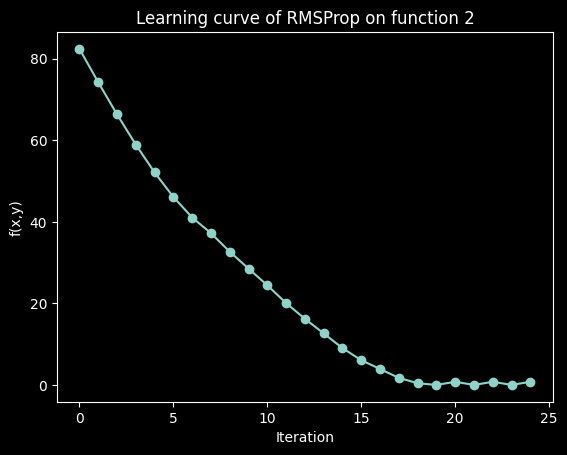

In [15]:
"""! @brief Initializes RMSProp for function f2 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
RMS2 = RMSProp(func2, Table(pd.DataFrame(), ["X","Y","Rho","Gamma","Iteration","Z min", "Z max","Z end"]))

# Executes the RMSProp algorithm
RMS2.run()

# CMA-ES

In [16]:
"""! @brief Declaration of the class CMA-ES"""

class CMAES:
    """! CMA-ES algorithm class
    Calibration and analysis of the CMA-ES algorithm with the given functions.
    """

    def __init__(self, fun: Function, table : Table):
        """! Initializes the CMA-ES class
        @param fun The function to be optimized.
        @param table A panda table to show data of the runs of the algorithm.

        @return An instance of the CMA-ES class with the function and the table.
        """
        #Number of iterations
        self.T = 25

        # Function to be optimized
        self.fun = fun

        # Table to store results
        self.table = table

        # Dummy value for mu
        self.mu = torch.tensor([0.0, 0.0])

    def cma_es(self, n: int, alpha: float, mu: torch.Tensor, sigma: torch.Tensor):
        """! Executes the CMA-ES algorithm
        @param n Size of the population.
        @param alpha Parameter alpha of the algorithm.
        @param mu Initial mean (center point) of the algorithm.
        @param sigma Initial covariance matrix of the algorithm.

        @return An array of the individuals in each iteration and its function value.
        """

        # Create lists for domain and codomain
        pts = []
        img = []

        # Execute the algorithm for a fixed number of times
        for i in range(self.T):

            # Normal distribution with mean mu and covariance matrix sigma.
            normal_dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=sigma)

            # Sample n points from the distribution.
            x_t = normal_dist.sample((n,))

            # Compute the function value of the points.
            y_t = self.fun.f(x_t[:, 0], x_t[:, 1], torch)

            # A vector for the weights of the points.
            w_t = torch.zeros_like(y_t)

            # Sort the points according to their function value from best to worst.
            sorted_indices = torch.argsort(y_t)

            # Assign the weights to the points according to their rank.
            w_t[sorted_indices] = 1.0 / (torch.arange(n) + 1)

            # Updates the mean with the weighted average of the new points.
            mu = mu + alpha * torch.sum(w_t[:, None] * (x_t - mu), dim=0)

            # Updates the covariance matrix with the weighted covariance matrix of the new points.
            sigma = (1 - alpha) * sigma + (alpha / n) * (x_t - mu).T @ (w_t[:, None] * (x_t - mu))

            # Saves the sample from the iteration.
            pts.append(x_t.tolist())
            img.append(y_t.tolist())

        # Return the visited points and the corresponding function values
        return pts, img


    def objetive(self, trial):
        """! Function for Optuna to optimize.
        @param trial An Optuna class.

        @return value of the function in this trial.
        """

        # Alpha suggested by Optuna in the range [1e-10, 5e-1].
        alpha = trial.suggest_float("alpha", 1e-10, 5e-1, log=True)

        # Number of points suggested by Optuna in the range [10, 150].
        n = trial.suggest_int("n", 10, 150, log=True)

        # Initial variance suggested by Optuna in the range [0.5, 1.5].
        sigma0 = trial.suggest_float("sigma0", 0.5, 1.5, log=True)

        # Visited values of the function.
        _, z= self.cma_es(n, alpha, self.mu, torch.tensor([[sigma0, 0], [0, sigma0]]))

        # Return the minimum of the last iteration.
        return min(z[-1])

    def study(self):
        """! Function to calibrate parameters with Optuna.
        @return The best parameters found as a dictionary.
        """
        # initial arbitrary center of the gaussian function
        self.mu = (torch.rand(2) * 20) - 10

        # To minimize the function.
        stud = optuna.create_study(direction="minimize")

        # Objective function and number of trials.
        stud.optimize(self.objetive, n_trials=50)

        # Print the best parameters found.
        print(stud.best_params)

        # Visualizations of the process provided by Optuna.
        optuna.visualization.plot_optimization_history(stud).show()
        optuna.visualization.plot_slice(stud, params=["n", "alpha", "sigma0"]).show()

        # Return the best parameters found.
        return stud.best_params

    def show_plots(self, n : int, alpha : float, mu : torch.Tensor, sigma : torch.Tensor):
        """ ! Function to show the plots of the best run.
        @param n Number of points in the population.
        @param alpha Parameter alpha of the algorithm.
        @param mu Initial mean (center point) of the algorithm.
        @param sigma Initial covariance matrix of the algorithm.
        """

        # Executes the optimization algorithm
        pts, img = self.cma_es(n,alpha, mu, sigma)

        # Shows only a fifth of the iterations (samples).
        for i in range(0, len(pts), 5):

            # Plots contour with optimization trajectory
            plot.make_contour_iteration(self.fun,[x[0] for x in pts[i]],[x[1] for x in pts[i]],f"CMA-ES Iteration {i}", self.fun.n)
            plot.show()

        # Show the learning curve (function value vs iterations)
        plot.make_plot([i for i in range(len(img))], [min(row) for row in img], "CMA-ES", self.fun.n)

    def run(self):
        """ ! Run 10 times the algorithm with the best parameters found in different initial points and shows the best run.
        """
        # Retrieve the best parameters from the study.
        best = self.study()

        # Assign the best parameters to the variables.
        n, alpha, sigma0 = best["n"], best["alpha"], best["sigma0"]

        # Build a initial covariance matrix.
        sigma0 = torch.tensor([[sigma0, 0], [0, sigma0]])

        # Initialize the iteration counter.
        it = 0

        # Initialize the best distance tracker:
        best_dist = [math.inf, math.inf]
        best_init = torch.tensor([math.inf, math.inf])

        # Initialize means of z values and numbers of iteration
        mean_z = 0
        mean_i = 0

        # Iterate over predefined initial points
        for i in INITIAL_POINTS:

            #Execute the CMA-ES algorithm
            pts, img = self.cma_es(n, alpha, i, sigma0)

            # The minimum and maximum value found.
            mn = [min(row) for row in img]
            mx = [max(row) for row in img]
            min_z = min(mn)
            max_z = max(mx)

            # Iteration where the minimum value was found.
            _i_ = mn.index(min(mn))

            # Store run info in the table.
            self.table.add(it, "N", n)
            self.table.add(it, "Alpha", alpha)
            self.table.add(it, "Sigma0", sigma0[0, 0].item())
            self.table.add(it, "Mu1", i[0].item())
            self.table.add(it, "Mu2", i[1].item())
            self.table.add(it, "Iteration", _i_)
            self.table.add(it, "Z min", min_z)
            self.table.add(it, "Z max", max_z)

            # Updates the best minimum value found and its iteration.
            if [min_z, _i_] < best_dist:
                best_dist = [min_z, _i_]
                best_init = i
            it += 1

            # Updates the mean of z values and the numbers of iteration
            mean_z += min_z
            mean_i += _i_

        # Calculate mean of the minimum of each run and its iterations.
        mean_z /= 10
        mean_i /= 10

        # Display the results.
        self.table.show()
        print(f"Mínimo promedio de Z en las 10 corridas: {mean_z}")
        print(f"Cantidad promedio de iteraciones para encontrar un mínimo: {math.ceil(mean_i)}")
        self.show_plots(n, alpha, best_init, sigma0)


[I 2026-05-12 00:56:13,990] A new study created in memory with name: no-name-7dc9c151-2394-483a-9c0a-bca4900e31fe
[I 2026-05-12 00:56:17,081] Trial 0 finished with value: 4.866771697998047 and parameters: {'alpha': 1.4480809072894055e-08, 'n': 24, 'sigma0': 1.0499614382724685}. Best is trial 0 with value: 4.866771697998047.
[I 2026-05-12 00:56:17,095] Trial 1 finished with value: 5.225367069244385 and parameters: {'alpha': 3.034996252595843e-08, 'n': 35, 'sigma0': 0.7829940767380896}. Best is trial 0 with value: 4.866771697998047.
[I 2026-05-12 00:56:17,109] Trial 2 finished with value: 4.66983699798584 and parameters: {'alpha': 1.8396188071849664e-05, 'n': 112, 'sigma0': 0.8185023605385573}. Best is trial 2 with value: 4.66983699798584.
[I 2026-05-12 00:56:17,123] Trial 3 finished with value: 4.858758449554443 and parameters: {'alpha': 4.164894895922069e-09, 'n': 17, 'sigma0': 0.7072886086872969}. Best is trial 2 with value: 4.66983699798584.
[I 2026-05-12 00:56:17,136] Trial 4 finish

{'alpha': 0.18602318496106346, 'n': 103, 'sigma0': 1.2222743418959923}


       N     Alpha    Sigma0       Mu1       Mu2  Iteration      Z min  \
0  103.0  0.186023  1.222274 -3.076737 -7.046052       10.0  -8.196314   
1  103.0  0.186023  1.222274 -8.789130  8.805107       24.0  -1.893884   
2  103.0  0.186023  1.222274 -8.915907  7.264505       24.0  -1.913196   
3  103.0  0.186023  1.222274 -2.639543 -1.743213       20.0  -5.054792   
4  103.0  0.186023  1.222274 -2.180393 -6.085358       21.0  -8.196398   
5  103.0  0.186023  1.222274 -8.630865 -8.735422       23.0 -11.337999   
6  103.0  0.186023  1.222274 -7.169003 -1.497990       17.0  -8.196365   
7  103.0  0.186023  1.222274 -3.004156  0.603686       22.0  -1.913213   
8  103.0  0.186023  1.222274  0.622189  1.721140       24.0  -1.913104   
9  103.0  0.186023  1.222274  5.598886  3.790258       17.0   1.228390   

        Z max  
0   42.600136  
1  480.377045  
2  433.258789  
3   35.977722  
4   55.032555  
5   15.909552  
6   91.373184  
7   62.557896  
8   34.739395  
9   28.018629  
Mínimo pr

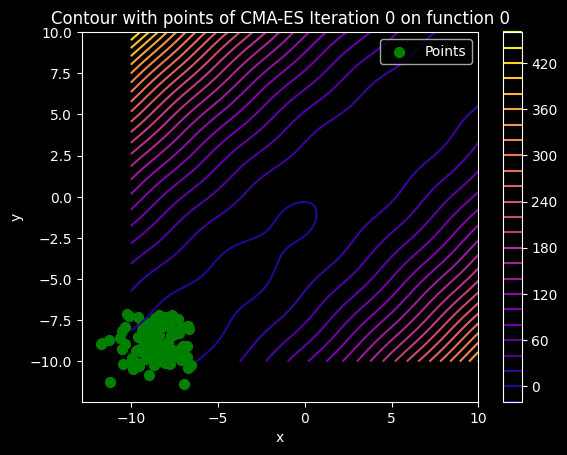

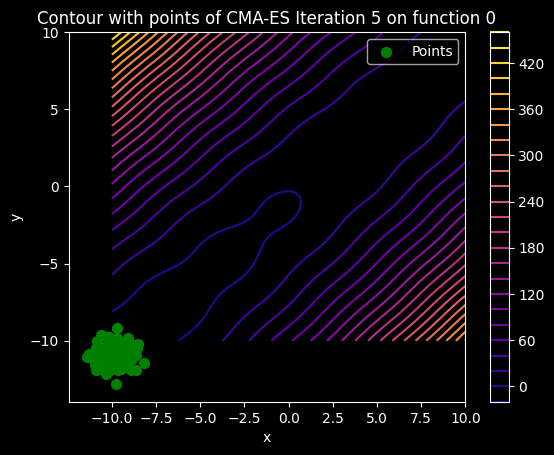

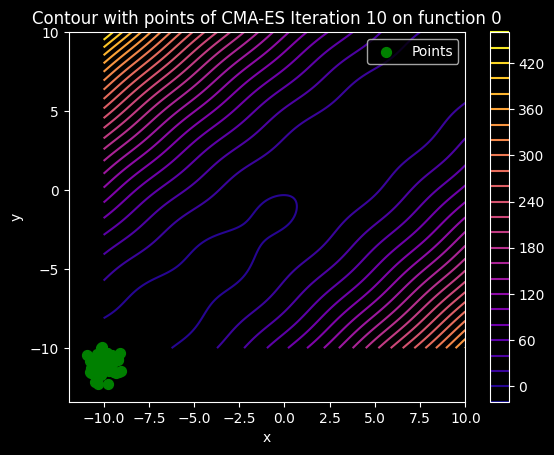

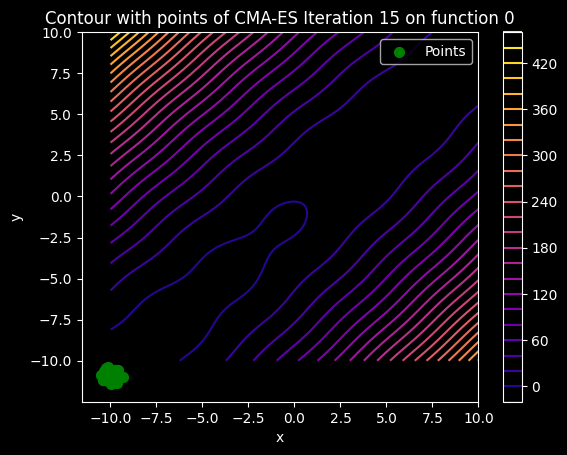

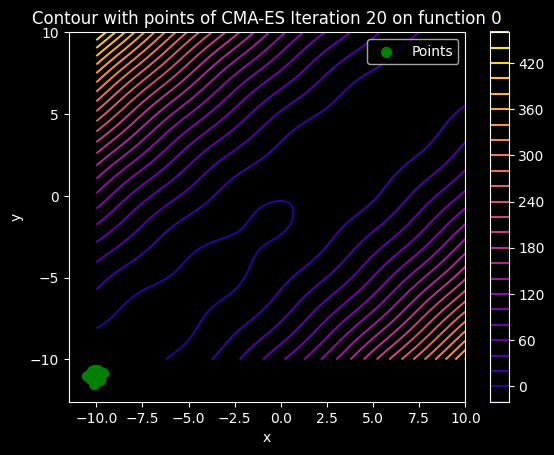

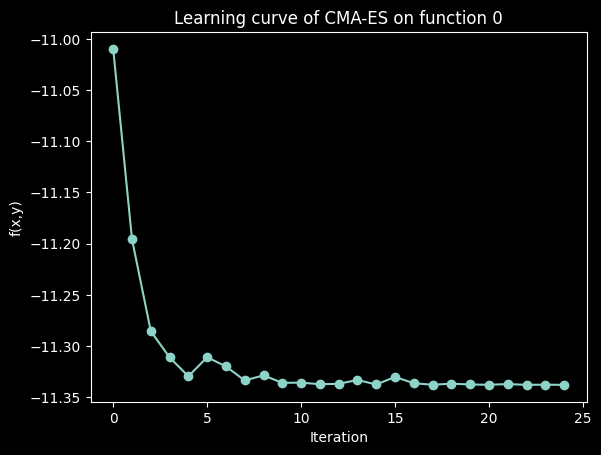

In [17]:
"""! @brief Initializes CMA-ES for function f0 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
cma0 = CMAES(func0,Table(pd.DataFrame(), ["N","Alpha","Sigma0","Mu1","Mu2","Iteration", "Z min", "Z max"]))

# Executes the CMA-ES algorithm
cma0.run()

[I 2026-05-12 00:56:27,729] A new study created in memory with name: no-name-b5b52dcd-aa85-4cd5-b427-7dd4be7c671f
[I 2026-05-12 00:56:27,750] Trial 0 finished with value: 0.1618814319372177 and parameters: {'alpha': 2.9779280355712973e-08, 'n': 94, 'sigma0': 0.7118205652143361}. Best is trial 0 with value: 0.1618814319372177.
[I 2026-05-12 00:56:27,766] Trial 1 finished with value: 0.3102923631668091 and parameters: {'alpha': 2.1801924252181403e-07, 'n': 30, 'sigma0': 1.0023516549537013}. Best is trial 0 with value: 0.1618814319372177.
[I 2026-05-12 00:56:27,783] Trial 2 finished with value: 0.8325636982917786 and parameters: {'alpha': 5.169977552543366e-05, 'n': 24, 'sigma0': 1.3250785443856095}. Best is trial 0 with value: 0.1618814319372177.
[I 2026-05-12 00:56:27,799] Trial 3 finished with value: 0.10062532126903534 and parameters: {'alpha': 2.1026856599211792e-06, 'n': 144, 'sigma0': 0.583969504385541}. Best is trial 3 with value: 0.10062532126903534.
[I 2026-05-12 00:56:27,816] T

{'alpha': 0.49620348048077456, 'n': 45, 'sigma0': 0.6008987760403645}


      N     Alpha    Sigma0       Mu1       Mu2  Iteration       Z min  \
0  45.0  0.496203  0.600899 -3.076737 -7.046052        6.0   26.420387   
1  45.0  0.496203  0.600899 -8.789130  8.805107       24.0   84.481827   
2  45.0  0.496203  0.600899 -8.915907  7.264505       24.0   37.898632   
3  45.0  0.496203  0.600899 -2.639543 -1.743213       23.0    0.000000   
4  45.0  0.496203  0.600899 -2.180393 -6.085358       22.0   32.178001   
5  45.0  0.496203  0.600899 -8.630865 -8.735422       24.0  150.724533   
6  45.0  0.496203  0.600899 -7.169003 -1.497990       23.0    9.666614   
7  45.0  0.496203  0.600899 -3.004156  0.603686       24.0    0.000000   
8  45.0  0.496203  0.600899  0.622189  1.721140       24.0    0.000000   
9  45.0  0.496203  0.600899  5.598886  3.790258       24.0    0.109874   

        Z max  
0  204.923019  
1  324.348724  
2  298.996429  
3   58.912857  
4  139.776489  
5  471.445007  
6  172.376465  
7   52.450684  
8   15.979058  
9   72.610229  
Mínimo pr

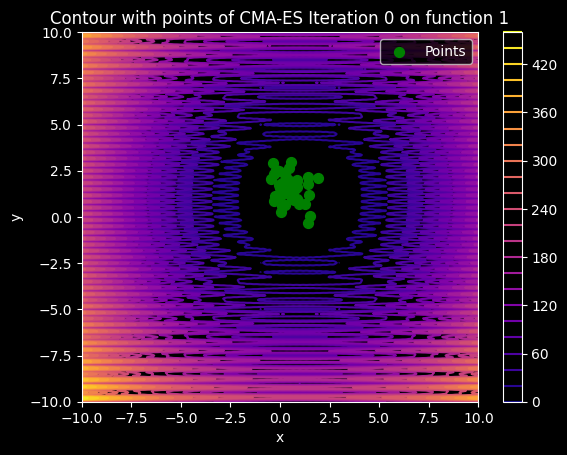

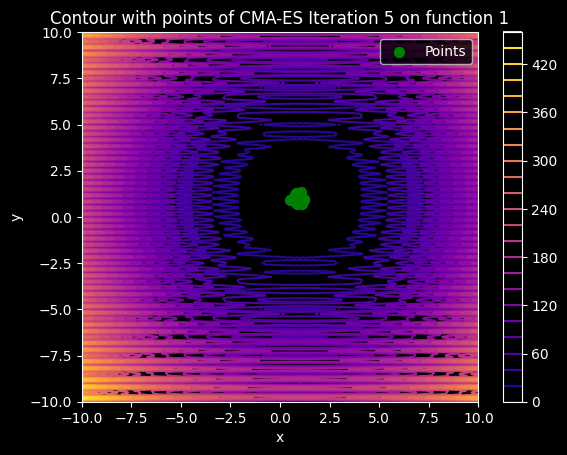

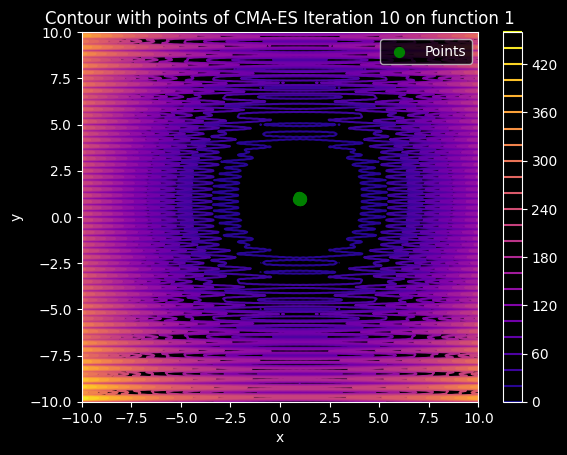

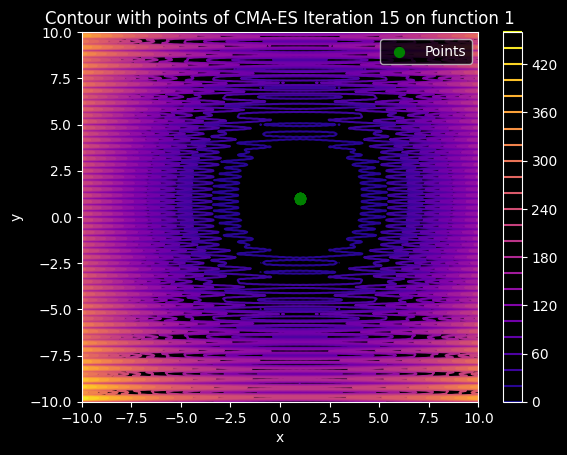

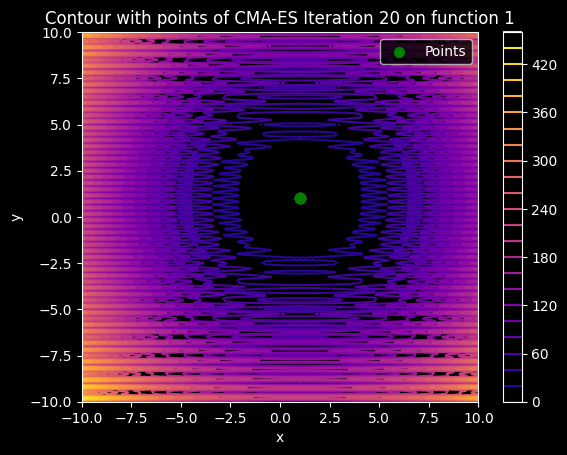

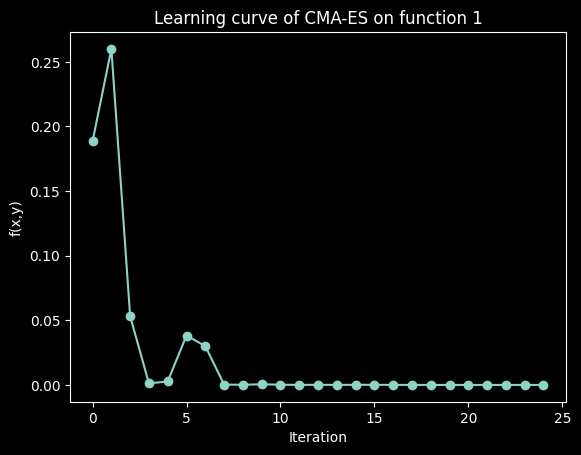

In [18]:
"""! @brief Initializes CMA-ES for function f1 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
cma1 = CMAES(func1, Table(pd.DataFrame(), ["N","Alpha","Sigma0","Mu1","Mu2","Iteration", "Z min", "Z max"]))

# Executes the CMA-ES algorithm
cma1.run()

[I 2026-05-12 00:56:34,128] A new study created in memory with name: no-name-128b1da9-8155-4fb8-b3ea-5a4052bfcdc9
[I 2026-05-12 00:56:34,148] Trial 0 finished with value: 1340.67626953125 and parameters: {'alpha': 4.593021545871666e-05, 'n': 58, 'sigma0': 0.7755666319871742}. Best is trial 0 with value: 1340.67626953125.
[I 2026-05-12 00:56:34,165] Trial 1 finished with value: 23.532133102416992 and parameters: {'alpha': 0.29447484092946163, 'n': 17, 'sigma0': 0.8882445327912265}. Best is trial 1 with value: 23.532133102416992.
[I 2026-05-12 00:56:34,181] Trial 2 finished with value: 668.1610107421875 and parameters: {'alpha': 2.5606397743795353e-08, 'n': 12, 'sigma0': 1.2308268282684742}. Best is trial 1 with value: 23.532133102416992.
[I 2026-05-12 00:56:34,200] Trial 3 finished with value: 1690.3377685546875 and parameters: {'alpha': 1.4232489582855345e-09, 'n': 111, 'sigma0': 0.8431846894566926}. Best is trial 1 with value: 23.532133102416992.
[I 2026-05-12 00:56:34,217] Trial 4 fi

{'alpha': 0.4967573175834619, 'n': 61, 'sigma0': 1.494290567539378}


      N     Alpha    Sigma0       Mu1       Mu2  Iteration     Z min  \
0  61.0  0.496757  1.494291 -3.076737 -7.046052       24.0  0.000001   
1  61.0  0.496757  1.494291 -8.789130  8.805107       23.0  0.000000   
2  61.0  0.496757  1.494291 -8.915907  7.264505       23.0  0.000000   
3  61.0  0.496757  1.494291 -2.639543 -1.743213       23.0  0.000000   
4  61.0  0.496757  1.494291 -2.180393 -6.085358       24.0  0.000000   
5  61.0  0.496757  1.494291 -8.630865 -8.735422       22.0  0.000000   
6  61.0  0.496757  1.494291 -7.169003 -1.497990       24.0  0.000000   
7  61.0  0.496757  1.494291 -3.004156  0.603686       24.0  0.000000   
8  61.0  0.496757  1.494291  0.622189  1.721140       24.0  0.000000   
9  61.0  0.496757  1.494291  5.598886  3.790258       18.0  0.000000   

          Z max  
0   8311.394531  
1  22175.433594  
2  34056.375000  
3    380.205902  
4   5104.801270  
5  20230.839844  
6   7505.113281  
7    361.473694  
8    689.887817  
9   4918.486328  
Mínimo pr

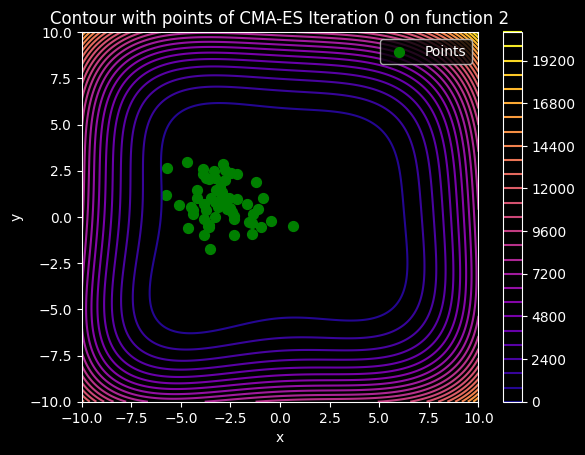

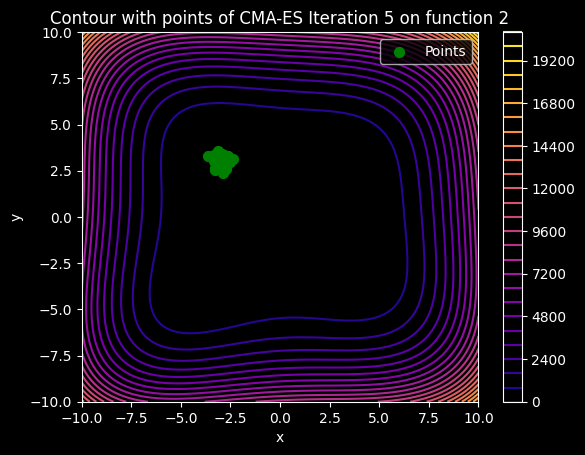

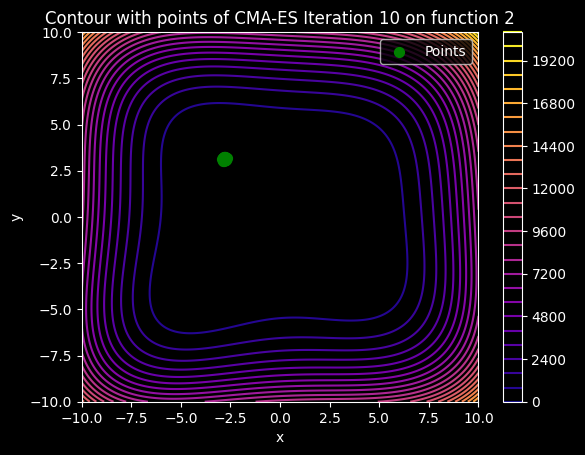

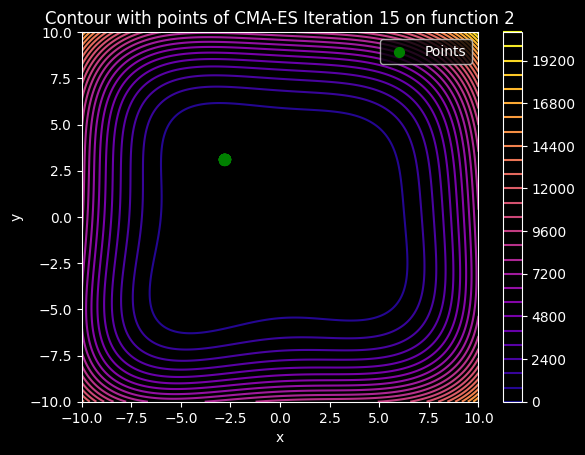

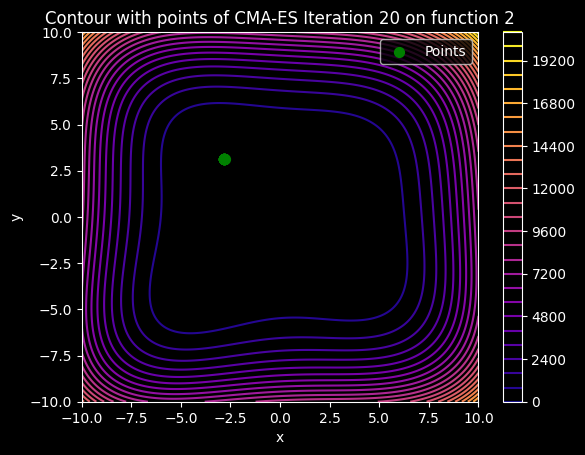

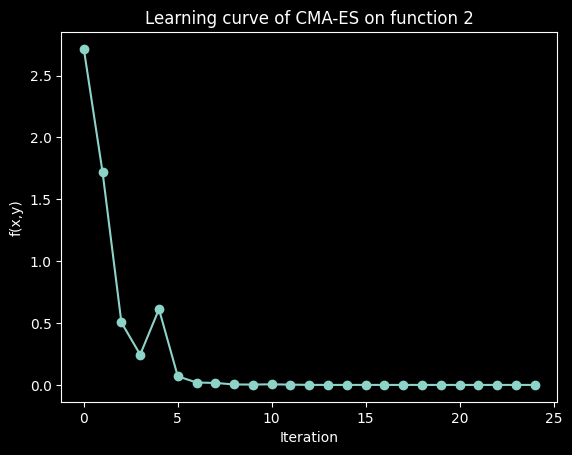

In [19]:
"""! @brief Initializes CMA-ES for function f2 and runs the algorithm """

# Initialize the class and creates a results table with relevant metrics.
cma2 = CMAES(func2, Table(pd.DataFrame(), ["N","Alpha","Sigma0","Mu1","Mu2","Iteration", "Z min", "Z max"]))

# Executes the CMA-ES algorithm
cma2.run()

# Pruebas Unitarias

## Descenso de gradiente

In [20]:
def test_gradient_descent_convergence():
    """Verify that GD reduces the value of the function"""
    gd = GradientDescent(func2, Table(pd.DataFrame(), []))

    # Initial point close to the known minimum of Himmelblau (~[3, 2])
    x0 = torch.tensor([3.5, 2.5])
    alpha = 0.01

    pts, img = gd.descent(alpha, x0)

    # The final value should be lower than the initial (generally)
    assert img[-1] <= img[0] + 1e-6, "The function don't have decreased during the descent"
    assert len(pts) == 25, "Incorrect number of iterations"

def test_gradient_descent_clamping():
    """Verify that the points are clamped to [-10, 10]"""
    gd = GradientDescent(func0, Table(pd.DataFrame(), []))

    x0 = torch.tensor([9.5, 9.5])  # Near to the limit
    alpha = 0.5  # Big step size

    pts, _ = gd.descent(alpha, x0)

    for x, y in pts:
        assert -10 <= x <= 10 and -10 <= y <= 10, f"Point outside of the range: ({x}, {y})"

print("Pass" if test_gradient_descent_convergence()==None and test_gradient_descent_clamping()==None else "Not pass")

Pass


## RMSProp

In [21]:
def test_rmsprop_convergence():
    """Verify that RMSProp reduces the function value"""
    rms = RMSProp(func2, Table(pd.DataFrame(), []))

    # Initial point close to the known minimum of Himmelblau (~[3, 2])
    x0 = torch.tensor([3.5, 2.5])
    # Small rho
    rho = 0.01
    # Recommended value for gamma
    gamma = 0.9

    pts, img = rms.descent(x0, rho, gamma)

    # The value should be less than the initial value (generally)
    assert img[-1] <= img[0] + 1e-6, "The function no decreased during the descent"
    assert len(pts) == 25, "Incorrect number of iterations"

def test_gradient_descent_clamping():
    """Verify that the points stay within [-10, 10]"""
    rms = RMSProp(func0, Table(pd.DataFrame(), []))

    x0 = torch.tensor([8.5, 8.5])  # Near to the limit
    rho = 0.01 # Small rho
    gamma = 0.9 # Recommended value for gamma

    pts, _ = rms.descent(x0, rho, gamma)

    for x, y in pts:
        assert -10 <= x <= 10 and -10 <= y <= 10, f"Point outside of the range: ({x}, {y})"

print("Pass" if test_gradient_descent_convergence()==None and test_gradient_descent_clamping()==None else "Not pass")

Pass


## CMA-ES

In [22]:
def test_cmaes_convergence():
    """Verify that CMA-ES reduces the function value"""
    cma = CMAES(func2, Table(pd.DataFrame(), []))

    n = 10 # Normal number of points
    alpha = 0.01 # Small alpha
    mu = torch.tensor([0.0, 0.0]) # Initial mean (center point)
    sigma0 = torch.tensor([[0.5, 0], [0, 0.5]]) # Initial covariance matrix

    pts, img = cma.cma_es(n, alpha, mu, sigma0)

    # The value should be less than the initial value (generally)
    assert img[-1] <= img[0] + 1e-6, "The function no decreased during the run"
    assert len(pts) == 25, "Incorrect number of iterations"

def test_gradient_descent_clamping():
    """Verify that the points stay within [-10, 10]"""
    cma = CMAES(func0, Table(pd.DataFrame(), []))

    n = 10 # Normal number of points
    alpha = 0.01 # Small alpha
    mu = torch.tensor([0.0, 0.0]) # Initial mean (center point)
    sigma0 = torch.tensor([[0.5, 0], [0, 0.5]]) # Initial covariance matrix

    pts, _ = cma.cma_es(n, alpha, mu, sigma0)

    for x, y in pts[0]:
        assert -10 <= x <= 10 and -10 <= y <= 10, f"Point outside of the range: ({x}, {y})"

print("Pass" if test_gradient_descent_convergence()==None and test_gradient_descent_clamping()==None else "Not pass")

Pass
